<a href="https://colab.research.google.com/github/JhanaviLingameneni/Prompted-ICU-Risk-Forecasting/blob/main/ML_Project_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Insights about Data
12,000 patient records total

set-a - 8,000 patients

set-b - 4,000 patients

4 columns  - PatientID | Time / Static | Parameter | Value

Time series rows format - HH:MM , Parameter , Value

recorded upto 48 hours

clinical variables


*  HR (Heart Rate)

*  Temp (Temperature)

*  RespRate (Respiratory Rate)

*  BP (Blood Pressure)

*  MAP (Mean Arterial Pressure)

*  SysABP (Systolic BP)

*  DiasABP (Diastolic BP)

*  SpO2 (Oxygen Saturation)

Outcome (target)

*  In-hospital_death (0 or 1)


Each patient file contains:

    1. time-series data (hourly vitals)

    2. static info (age, gender)
##Metrics


1.   Accuracy

     Out of all predictions, how many were correct? Misleading when data is imbalanced

2.   Precision
     
     Out of all patients predicted as “high risk”, how many were actually high risk?Avoid false alarms
3.   Recall

     Out of all actual high-risk patients, how many did we correctly detect?Avoid missing sick patients
4.   F1 Score

     Balance between precision and recall

5.   ROC-AUC

     Measures how well the model separates:

     high-risk vs low-risk patients

what we want - predicts patient death(high-risk)
False Negative (FN) -
Patient is sick

Model says “safe” - danger

False Positive (FP) -
Patient is safe

Model says “risk”

Just extra check → acceptable


So recall is important - How many sick patients did we catch

High recall - fewer missing patients

In healthcare, it’s better to over-detect than to miss a critical case







In [29]:
import os #allows python to interact with OS for listing folders, file paths
import zipfile #used to extract zip files
import numpy as np #for numerical computation
import pandas as pd #for data manipulation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler #for normalizing features

In [30]:
#extracts the dataset zip file into a folder
zip_path = "/content/predicting-mortality-of-icu-patients-the-physionet-computing-in-cardiology-challenge-2012-1.0.0.zip"
extract_path = "/content/patient_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted to:", extract_path)

Files extracted to: /content/patient_data


In [31]:
# to check the folder structure and the main dataset
base_path = "/content/patient_data/predicting-mortality-of-icu-patients-the-physionet-computing-in-cardiology-challenge-2012-1.0.0"

print(os.listdir(base_path)) #lists everything in the folder

['set-a', 'Outcomes-a.txt', 'set-a.zip', 'Outcomes-b.txt', 'Outcomes-c.txt', 'set-b', 'set-b.zip']


In [32]:
#loads patient files and split them into static data and dynamic data
all_timeseries = [] # to store time series data
all_static = [] # to store patients metadata(static)

#loops through every patients data
for folder in ["set-a", "set-b"]:
    folder_path = os.path.join(base_path, folder)
    print("Reading:", folder_path)

    for file in os.listdir(folder_path):
        if file.endswith(".txt"):
            file_path = os.path.join(folder_path, file)
            patient_id = file.replace(".txt", "")

            df = pd.read_csv(
                file_path,
                header=None,
                names=["Col1", "Col2", "Col3"]
            )

            df["PatientID"] = patient_id

            # time-series rows: 00:00, 01:30, etc.
            ts = df[df["Col1"].astype(str).str.match(r"^\d{2}:\d{2}$", na=False)].copy()
            ts = ts.rename(columns={"Col1": "Time", "Col2": "Parameter", "Col3": "Value"})
            ts["Value"] = pd.to_numeric(ts["Value"], errors="coerce")
            all_timeseries.append(ts[["PatientID", "Time", "Parameter", "Value"]])

            # static rows: Age, Gender, Height, ICUType, Weight, etc.
            static = df[~df["Col1"].astype(str).str.match(r"^\d{2}:\d{2}$", na=False)].copy()
            static = static.rename(columns={"Col1": "Parameter", "Col2": "Value"})
            static = static[["PatientID", "Parameter", "Value"]]
            static["Value"] = pd.to_numeric(static["Value"], errors="coerce")
            all_static.append(static)

raw_ts = pd.concat(all_timeseries, ignore_index=True)
raw_static = pd.concat(all_static, ignore_index=True)

print("Time-series shape:", raw_ts.shape)
print("Static shape:", raw_static.shape)

raw_ts.head()

Reading: /content/patient_data/predicting-mortality-of-icu-patients-the-physionet-computing-in-cardiology-challenge-2012-1.0.0/set-a
Reading: /content/patient_data/predicting-mortality-of-icu-patients-the-physionet-computing-in-cardiology-challenge-2012-1.0.0/set-b
Time-series shape: (3520515, 4)
Static shape: (8000, 3)


,PatientID,Time,Parameter,Value
0,135797,00:00,RecordID,135797.0
1,135797,00:00,Age,78.0
2,135797,00:00,Gender,1.0
3,135797,00:00,Height,172.7
4,135797,00:00,ICUType,2.0


In [33]:
#convert time to hours - 00:30 ->00:30:00
raw_ts["Time"] = pd.to_timedelta(raw_ts["Time"] + ":00")
raw_ts["Hour"] = raw_ts["Time"].dt.total_seconds() / 3600.0

raw_ts[["PatientID", "Time", "Hour", "Parameter", "Value"]].head()

,PatientID,Time,Hour,Parameter,Value
0,135797,0 days,0.0,RecordID,135797.0
1,135797,0 days,0.0,Age,78.0
2,135797,0 days,0.0,Gender,1.0
3,135797,0 days,0.0,Height,172.7
4,135797,0 days,0.0,ICUType,2.0


In [34]:
#converting long format to proper table (wide format)-------- | PatientID | Time | Parameter | Value | -> PatientID     Hour    HR     Temp     SpO2
wide_data = raw_ts.pivot_table(
    index=["PatientID", "Hour"],
    columns="Parameter",
    values="Value",
    aggfunc="mean"
).reset_index()

wide_data.columns.name = None
wide_data = wide_data.sort_values(["PatientID", "Hour"]).reset_index(drop=True)

print("Wide data shape:", wide_data.shape)
wide_data.head()

Wide data shape: (598332, 44)


,PatientID,Hour,ALP,ALT,AST,Age,Albumin,BUN,Bilirubin,Cholesterol,...,RespRate,SaO2,SysABP,Temp,TroponinI,TroponinT,Urine,WBC,Weight,pH
0,132539,0.000000,NaN,NaN,NaN,54.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,NaN
1,132539,0.116667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,19.0,NaN,NaN,35.1,NaN,NaN,900.0,NaN,NaN,NaN
2,132539,0.616667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,19.0,NaN,NaN,35.6,NaN,NaN,60.0,NaN,NaN,NaN
3,132539,1.616667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,18.0,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN
4,132539,2.616667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,19.0,NaN,NaN,NaN,NaN,NaN,170.0,NaN,NaN,NaN


In [35]:
# resampling to hourly timeline
#Different patients may have measurements at different times:
#one patient may have hour 0, 2, 5
#another may have hour 1, 3, 4
#But sequence models need a consistent timeline.
#So you create a fixed timeline:
#That means:
#hour 0
#hour 1
#hour 2
#...
#hour 48
#So every patient gets 49 hourly slots.

def resample_patient(group): #processing 1 patient at a time
    group = group.sort_values("Hour").copy() #sorting time
    group = group.set_index("Hour") #sorting index

    full_index = np.arange(0, 49, 1)   # creating full 48-hour timeline 0 to 48 hours
    group = group.reindex(full_index)
    group.index.name = "Hour"

    group["PatientID"] = group["PatientID"].ffill().bfill()
    group = group.reset_index()
    return group

resampled_data = wide_data.groupby("PatientID", group_keys=False).apply(resample_patient)
resampled_data = resampled_data.reset_index(drop=True)

print("Resampled shape:", resampled_data.shape)
resampled_data.head(10)

Resampled shape: (392000, 44)


/tmp/ipykernel_325/60175458.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resampled_data = wide_data.groupby("PatientID", group_keys=False).apply(resample_patient)


,Hour,PatientID,ALP,ALT,AST,Age,Albumin,BUN,Bilirubin,Cholesterol,...,RespRate,SaO2,SysABP,Temp,TroponinI,TroponinT,Urine,WBC,Weight,pH
0,0,132539,NaN,NaN,NaN,54.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,NaN
1,1,132539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,132539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,132539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,132539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,132539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6,132539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7,132539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,8,132539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,9,132539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
#fill missing values
feature_cols = [col for col in resampled_data.columns if col not in ["PatientID", "Hour"]]

resampled_data[feature_cols] = (
    resampled_data.groupby("PatientID")[feature_cols]
    .ffill()
    .bfill()
)
#If some feature is still missing for a patient even after ffill/bfill, you fill with the overall median.
global_medians = resampled_data[feature_cols].median(numeric_only=True)
resampled_data[feature_cols] = resampled_data[feature_cols].fillna(global_medians)

print("Remaining missing values:", resampled_data[feature_cols].isnull().sum().sum())

Remaining missing values: 0


In [37]:
# creating static patient table
static_keep = ["RecordID", "Age", "Gender", "Height", "ICUType", "Weight"]

static_data = raw_static[raw_static["Parameter"].isin(static_keep)].copy()

static_wide = static_data.pivot_table(
    index="PatientID",
    columns="Parameter",
    values="Value",
    aggfunc="first"
).reset_index()

static_wide.columns.name = None

print("Static wide shape:", static_wide.shape)
static_wide.head()

Static wide shape: (0, 1)


,PatientID


In [38]:
#loading outcome labels
outcomes_a = pd.read_csv(os.path.join(base_path, "Outcomes-a.txt"))
outcomes_b = pd.read_csv(os.path.join(base_path, "Outcomes-b.txt"))

outcomes = pd.concat([outcomes_a, outcomes_b], ignore_index=True)

print("Outcomes shape:", outcomes.shape)
outcomes.head()

Outcomes shape: (8000, 6)


,RecordID,SAPS-I,SOFA,Length_of_stay,Survival,In-hospital_death
0,132539,6,1,5,-1,0
1,132540,16,8,8,-1,0
2,132541,21,11,19,-1,0
3,132543,7,1,9,575,0
4,132545,17,2,4,918,0


In [39]:
#merging everything
resampled_data["PatientID"] = resampled_data["PatientID"].astype(int)
static_wide["PatientID"] = static_wide["PatientID"].astype(int)
outcomes["RecordID"] = outcomes["RecordID"].astype(int)

merged_data = resampled_data.merge(static_wide, on="PatientID", how="left")
merged_data = merged_data.merge(outcomes, left_on="PatientID", right_on="RecordID", how="left")

print("Merged data shape:", merged_data.shape)
merged_data.head()

Merged data shape: (392000, 50)


,Hour,PatientID,ALP,ALT,AST,Age,Albumin,BUN,Bilirubin,Cholesterol,...,Urine,WBC,Weight,pH,RecordID_y,SAPS-I,SOFA,Length_of_stay,Survival,In-hospital_death
0,0,132539,64.0,12.0,12.0,54.0,3.1,37.0,0.4,101.0,...,80.0,9.4,-1.0,7.34,132539,6,1,5,-1,0
1,1,132539,64.0,12.0,12.0,54.0,3.1,37.0,0.4,101.0,...,80.0,9.4,-1.0,7.34,132539,6,1,5,-1,0
2,2,132539,64.0,12.0,12.0,54.0,3.1,37.0,0.4,101.0,...,80.0,9.4,-1.0,7.34,132539,6,1,5,-1,0
3,3,132539,64.0,12.0,12.0,54.0,3.1,37.0,0.4,101.0,...,80.0,9.4,-1.0,7.34,132539,6,1,5,-1,0
4,4,132539,64.0,12.0,12.0,54.0,3.1,37.0,0.4,101.0,...,80.0,9.4,-1.0,7.34,132539,6,1,5,-1,0


In [40]:
merged_data.to_csv("/content/cleaned_physionet_timeseries.csv", index=False)
print("Saved: /content/cleaned_physionet_timeseries.csv")

Saved: /content/cleaned_physionet_timeseries.csv


Why do we create ML features (mean, min, max, std)?

Because classical ML models cannot understand time-series data directly, so we convert it into a fixed set of summary features.
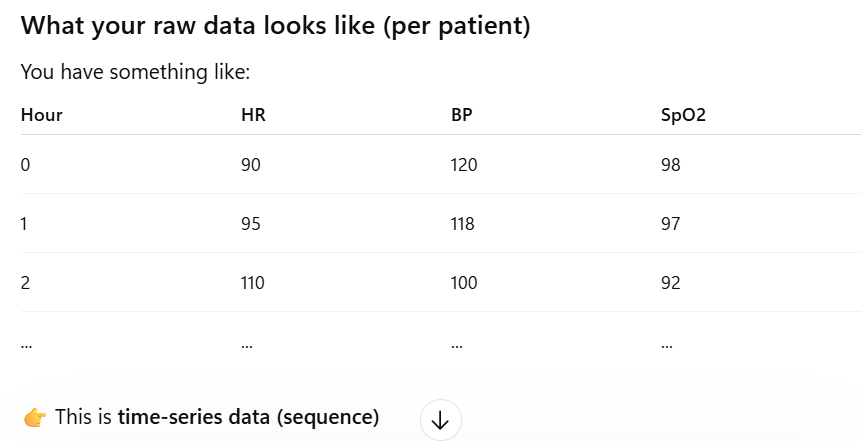
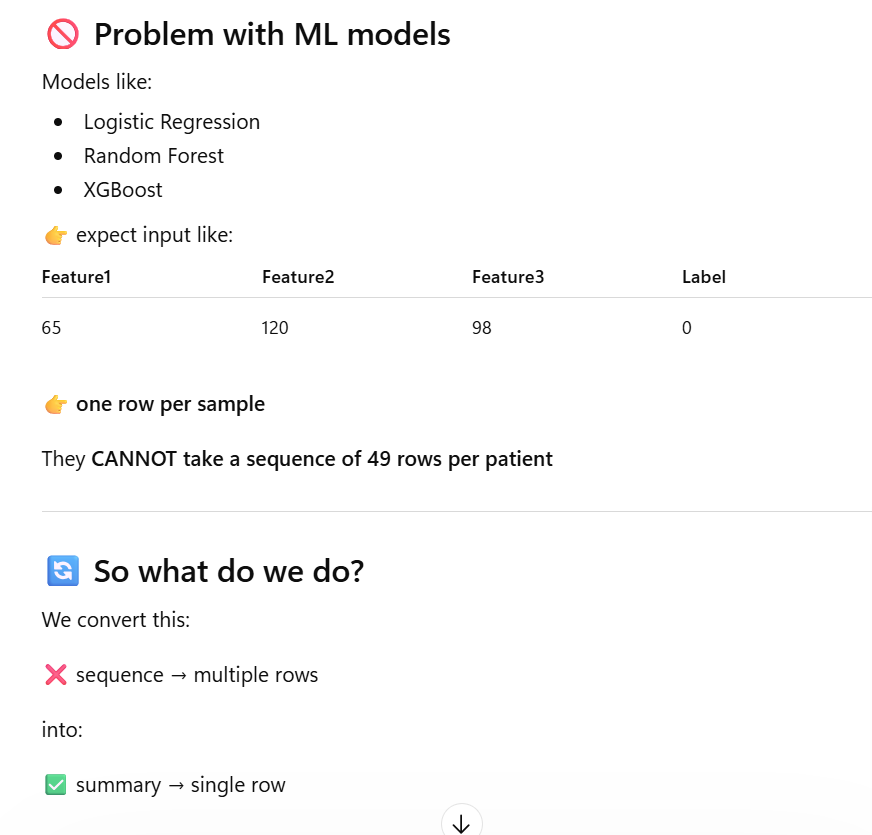
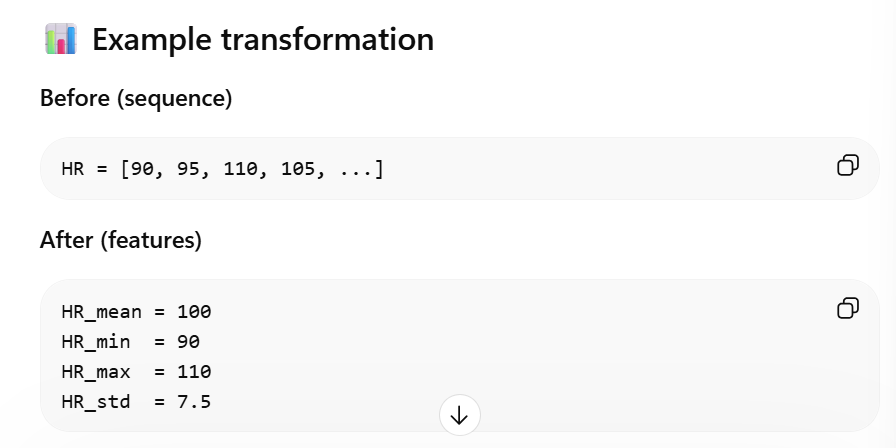

In [41]:
# Create ML features safely without leakage
#Because classical ML models cannot understand time-series data directly, so we convert it into a fixed set of summary features.
# Keep only time-series feature columns that are actually present
ts_feature_cols = [col for col in feature_cols if col in merged_data.columns]

# Aggregate dynamic features per patient
patient_features = merged_data.groupby("PatientID")[ts_feature_cols].agg(["mean", "min", "max", "std"])
patient_features.columns = ["_".join(col).strip() for col in patient_features.columns]
patient_features = patient_features.reset_index()

# Static features
static_patient = static_wide.copy()

# Keep ONLY the target from outcomes
target_data = outcomes[["RecordID", "In-hospital_death"]].rename(columns={"RecordID": "PatientID"})

# Merge safely
final_ml_data_clean = patient_features.merge(static_patient, on="PatientID", how="left")
final_ml_data_clean = final_ml_data_clean.merge(target_data, on="PatientID", how="left")

# Fill missing values
final_ml_data_clean = final_ml_data_clean.fillna(final_ml_data_clean.median(numeric_only=True))

print("Final clean ML data shape:", final_ml_data_clean.shape)
final_ml_data_clean.head()

Final clean ML data shape: (8000, 166)


,PatientID,ALP_mean,ALP_min,ALP_max,ALP_std,ALT_mean,ALT_min,ALT_max,ALT_std,AST_mean,...,WBC_std,Weight_mean,Weight_min,Weight_max,Weight_std,pH_mean,pH_min,pH_max,pH_std,In-hospital_death
0,132539,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.0,-1.0,-1.0,-1.0,0.0,7.34,7.34,7.34,0.0,0
1,132540,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.0,76.0,76.0,76.0,0.0,7.34,7.34,7.34,0.0,0
2,132541,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.0,56.7,56.7,56.7,0.0,7.34,7.34,7.34,0.0,0
3,132543,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.0,84.6,84.6,84.6,0.0,7.34,7.34,7.34,0.0,0
4,132545,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.0,-1.0,-1.0,-1.0,0.0,7.34,7.34,7.34,0.0,0


In [42]:
print(final_ml_data_clean.shape)
final_ml_data_clean.head(10)

(8000, 166)


,PatientID,ALP_mean,ALP_min,ALP_max,ALP_std,ALT_mean,ALT_min,ALT_max,ALT_std,AST_mean,...,WBC_std,Weight_mean,Weight_min,Weight_max,Weight_std,pH_mean,pH_min,pH_max,pH_std,In-hospital_death
0,132539,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.0,-1.0,-1.0,-1.0,0.0,7.34,7.34,7.34,0.0,0
1,132540,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.0,76.0,76.0,76.0,0.0,7.34,7.34,7.34,0.0,0
2,132541,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.0,56.7,56.7,56.7,0.0,7.34,7.34,7.34,0.0,0
3,132543,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.0,84.6,84.6,84.6,0.0,7.34,7.34,7.34,0.0,0
4,132545,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.0,-1.0,-1.0,-1.0,0.0,7.34,7.34,7.34,0.0,0
5,132547,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.0,114.0,114.0,114.0,0.0,7.34,7.34,7.34,0.0,0
6,132548,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.0,87.0,87.0,87.0,0.0,7.34,7.34,7.34,0.0,0
7,132551,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.0,48.4,48.4,48.4,0.0,7.34,7.34,7.34,0.0,1
8,132554,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.0,60.7,60.7,60.7,0.0,7.34,7.34,7.34,0.0,0
9,132555,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.0,66.1,66.1,66.1,0.0,7.34,7.34,7.34,0.0,0


In [43]:
target_col = "In-hospital_death"

X = final_ml_data_clean.drop(columns=["PatientID", target_col])
y = final_ml_data_clean[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (8000, 164)
y shape: (8000,)
In-hospital_death
0    6878
1    1122
Name: count, dtype: int64


In [44]:
from sklearn.model_selection import train_test_split

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train_df.shape)
print("Test shape:", X_test_df.shape)

Train shape: (6400, 164)
Test shape: (1600, 164)


In [45]:
from sklearn.feature_selection import VarianceThreshold
#This removes columns with zero variance.
#Meaning:
#If a feature is constant for every patient, it gives no useful information.
#Example:
#If one column is always the same number, the model learns nothing from it.

selector = VarianceThreshold(threshold=0)

X_train_sel = selector.fit_transform(X_train_df)
X_test_sel = selector.transform(X_test_df)

print("Selected train shape:", X_train_sel.shape)
print("Selected test shape:", X_test_sel.shape)

Selected train shape: (6400, 152)
Selected test shape: (1600, 152)


In [46]:
#This standardizes features so each has:
#mean ≈ 0
#standard deviation ≈ 1
#Why needed:
#Models like Logistic Regression work better when features are on similar scales.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_sel)
X_test = scaler.transform(X_test_sel)

print("Scaled X_train shape:", X_train.shape)
print("Scaled X_test shape:", X_test.shape)

Scaled X_train shape: (6400, 152)
Scaled X_test shape: (1600, 152)


In [47]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    matthews_corrcoef
)

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_train_prob = model.predict_proba(X_train)[:, 1]
        y_test_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_train_prob = model.decision_function(X_train)
        y_test_prob = model.decision_function(X_test)
    else:
        y_train_prob = None
        y_test_prob = None

    def get_metrics(y_true, y_pred, y_prob=None):
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        metrics_dict = {
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1-Score": f1_score(y_true, y_pred, zero_division=0),
            "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
            "Specificity": specificity,
            "MCC": matthews_corrcoef(y_true, y_pred),
            "ROC-AUC": roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan
        }
        return metrics_dict, cm

    train_metrics, train_cm = get_metrics(y_train, y_train_pred, y_train_prob)
    test_metrics, test_cm = get_metrics(y_test, y_test_pred, y_test_prob)

    results_df = pd.DataFrame([train_metrics, test_metrics], index=["Train", "Test"])

    print(f"\n========== {model_name} ==========")
    print("\nMetrics Table:")
    print(results_df.round(4))

    print("\nTrain Confusion Matrix:")
    print(train_cm)

    print("\nTest Confusion Matrix:")
    print(test_cm)

    print("\nTrain Classification Report:")
    print(classification_report(y_train, y_train_pred, zero_division=0))

    print("\nTest Classification Report:")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    return results_df

##LOGISTIC REGRESSION

A linear model for binary classification.

It tries to learn a weighted combination of features and then outputs a probability.

Good for:
1.  simple baseline
2.  interpretable model

Weakness : may fail on complex nonlinear medical data

In [48]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_results = evaluate_model(
    lr_model,
    X_train, y_train,
    X_test, y_test,
    model_name="Logistic Regression"
)


========== Logistic Regression ==========

Metrics Table:
       Accuracy  Precision  Recall  F1-Score  Balanced Accuracy  Specificity  \
Train    0.8612     0.8125  0.0145    0.0284             0.5070       0.9995   
Test     0.8612     1.0000  0.0089    0.0177             0.5045       1.0000   

          MCC  ROC-AUC  
Train  0.0969   0.6561  
Test   0.0877   0.6385  

Train Confusion Matrix:
[[5499    3]
 [ 885   13]]

Test Confusion Matrix:
[[1376    0]
 [ 222    2]]

Train Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93      5502
           1       0.81      0.01      0.03       898

    accuracy                           0.86      6400
   macro avg       0.84      0.51      0.48      6400
weighted avg       0.85      0.86      0.80      6400


Test Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93      1376
           1       1.00    

##RANDOM FOREST
An ensemble of many decision trees.
Each tree votes, and the forest combines them.

Good for:

1.   nonlinear relationships
2.   tabular data

Weakness:
may ignore sequence timing because you already summarized the patient into one row

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_results = evaluate_model(
    rf_model,
    X_train, y_train,
    X_test, y_test,
    model_name="Random Forest"
)


========== Random Forest ==========

Metrics Table:
       Accuracy  Precision  Recall  F1-Score  Balanced Accuracy  Specificity  \
Train    1.0000     1.0000  1.0000    1.0000             1.0000        1.000   
Test     0.8525     0.3125  0.0446    0.0781             0.5143        0.984   

         MCC  ROC-AUC  
Train  1.000   1.0000  
Test   0.071   0.5872  

Train Confusion Matrix:
[[5502    0]
 [   0  898]]

Test Confusion Matrix:
[[1354   22]
 [ 214   10]]

Train Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5502
           1       1.00      1.00      1.00       898

    accuracy                           1.00      6400
   macro avg       1.00      1.00      1.00      6400
weighted avg       1.00      1.00      1.00      6400


Test Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      1376
           1       0.31      0.04   

##XGBoost
A boosting model that builds trees sequentially, each correcting the previous one.

Good for:
1.  strong tabular performance
2.   complex feature interactions

Weakness :
still not a true time-series model

In [50]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_results = evaluate_model(
    xgb_model,
    X_train, y_train,
    X_test, y_test,
    model_name="XGBoost"
)


========== XGBoost ==========

Metrics Table:
       Accuracy  Precision  Recall  F1-Score  Balanced Accuracy  Specificity  \
Train    0.8703     0.9595  0.0791    0.1461             0.5393       0.9995   
Test     0.8550     0.1000  0.0045    0.0085             0.4990       0.9935   

          MCC  ROC-AUC  
Train  0.2551   0.9017  
Test  -0.0091   0.6421  

Train Confusion Matrix:
[[5499    3]
 [ 827   71]]

Test Confusion Matrix:
[[1367    9]
 [ 223    1]]

Train Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      5502
           1       0.96      0.08      0.15       898

    accuracy                           0.87      6400
   macro avg       0.91      0.54      0.54      6400
weighted avg       0.88      0.87      0.82      6400


Test Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92      1376
           1       0.10      0.00      

In [51]:
ml_results = pd.concat(
    {
        "Logistic Regression": lr_results,
        "Random Forest": rf_results,
        "XGBoost": xgb_results
    }
)

print("\n========== ALL ML MODELS COMPARISON ==========")
print(ml_results.round(4))


========== ALL ML MODELS COMPARISON ==========
                           Accuracy  Precision  Recall  F1-Score  \
Logistic Regression Train    0.8612     0.8125  0.0145    0.0284   
                    Test     0.8612     1.0000  0.0089    0.0177   
Random Forest       Train    1.0000     1.0000  1.0000    1.0000   
                    Test     0.8525     0.3125  0.0446    0.0781   
XGBoost             Train    0.8703     0.9595  0.0791    0.1461   
                    Test     0.8550     0.1000  0.0045    0.0085   

                           Balanced Accuracy  Specificity     MCC  ROC-AUC  
Logistic Regression Train             0.5070       0.9995  0.0969   0.6561  
                    Test              0.5045       1.0000  0.0877   0.6385  
Random Forest       Train             1.0000       1.0000  1.0000   1.0000  
                    Test              0.5143       0.9840  0.0710   0.5872  
XGBoost             Train             0.5393       0.9995  0.2551   0.9017  
             

##LSTM
Long Short-Term Memory

data is time-series (patient condition changes over time), and LSTM is designed to learn patterns across time.

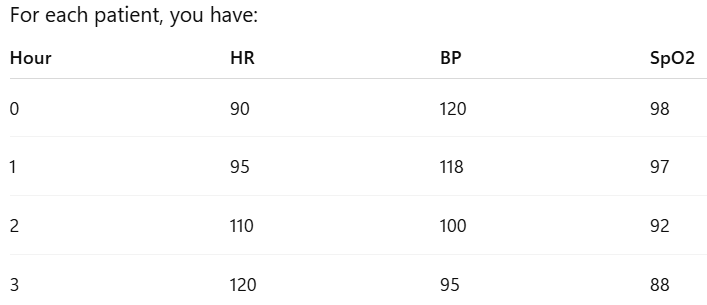

Doctors don't just look at values — they look at trends

for example:
Patient A: HR: 90 → 92 → 94 → 96 (Stable → probably safe)

Patient B: HR: 90 → 110 → 130 → 150 (Rapid increase → danger)

Why other models fail:
when we do mean, min, max, standard deviation
we convery values like : [90 → 110 → 130 → 150] this to mean = 120, min = 90, max = 150, std = high. we lose the order

So ML cannot tell:
gradual increase
sudden drop
timing of events

Why LSTM is perfect
LSTM = Long Short-Term Memory

At each time step:
t = 0 → sees HR = 90

t = 1 → remembers 90, sees 95

t = 2 → remembers trend, sees 110

t = 3 → detects rising pattern

It keeps memory of previous states

What LSTM learns in your case
1. Trends

increasing HR → risk

decreasing BP → risk

2. Temporal patterns

sudden drop vs gradual drop

early vs late deterioration

3. Dependencies

Example:

low SpO2 + high HR together → danger

4. Timing

abnormal values at hour 2 vs hour 40 → different meaning

Attention BiLSTM is even better

Bidirectional : looks forward and backward in sequence

understands full context

focuses on important time steps

Example:
at hour 10 (critical drop) matters more than hour 1



In [52]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, Masking,
    Bidirectional, BatchNormalization,
    Attention, GlobalAveragePooling1D,
    Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

In [53]:
#shouldnt choose these columns because of data leakage
leakage_cols = [
    "RecordID",
    "In-hospital_death",
    "Survival",
    "Length_of_stay",
    "SAPS-I",
    "SOFA"
]

id_time_cols = ["PatientID", "Hour"]

sequence_feature_cols = [
    col for col in merged_data.columns
    if col not in leakage_cols + id_time_cols
]

print("Number of sequence features:", len(sequence_feature_cols))
print(sequence_feature_cols[:20])

Number of sequence features: 43
['ALP', 'ALT', 'AST', 'Age', 'Albumin', 'BUN', 'Bilirubin', 'Cholesterol', 'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Gender', 'Glucose', 'HCO3', 'HCT', 'HR', 'Height', 'ICUType', 'K']


In [54]:
# merged_data has many rows per patient, one for each hour
#But the target is one label per patient:
#0 = survived
#1 = died in hospital*/
#So this code creates one clean target table
#Take only patient ID and label
#Keep only one row per patient
#Sort by patient ID.
#Reset row numbering.


patient_targets = (
    merged_data[["PatientID", "In-hospital_death"]]
    .drop_duplicates(subset=["PatientID"])
    .sort_values("PatientID")
    .reset_index(drop=True)
)

print(patient_targets.head())
print(patient_targets["In-hospital_death"].value_counts())

   PatientID  In-hospital_death
0     132539                  0
1     132540                  0
2     132541                  0
3     132543                  0
4     132545                  0
In-hospital_death
0    6878
1    1122
Name: count, dtype: int64


In [55]:
train_ids, test_ids = train_test_split(
    patient_targets["PatientID"],
    test_size=0.2,
    random_state=42,
    stratify=patient_targets["In-hospital_death"]
)

train_ids = set(train_ids)
test_ids = set(test_ids)

train_df = merged_data[merged_data["PatientID"].isin(train_ids)].copy()
test_df = merged_data[merged_data["PatientID"].isin(test_ids)].copy()

print("Train patients:", train_df["PatientID"].nunique())
print("Test patients:", test_df["PatientID"].nunique())

Train patients: 6400
Test patients: 1600


In [56]:
#Your features may be on different ranges:
#HR ~ 80
#Temp ~ 37
#WBC ~ maybe 10
#BP ~ 120
#Neural networks train better when features are standardized
seq_scaler = StandardScaler()

train_df[sequence_feature_cols] = seq_scaler.fit_transform(train_df[sequence_feature_cols])
test_df[sequence_feature_cols] = seq_scaler.transform(test_df[sequence_feature_cols])

building patience sequence

We convert each patient's data into a time-ordered list of values so the LSTM can understand how their condition changes over time.

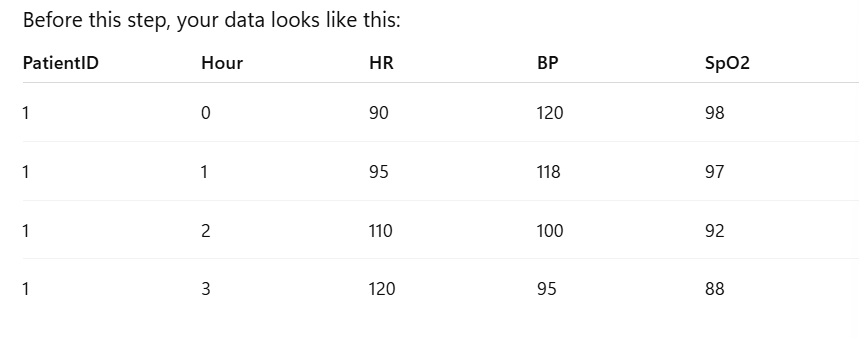

this has multiple rows for 1 patient

LSTM expects input like:
Patient 1:
[
  [90, 120, 98],   ← hour 0
  [95, 118, 97],   ← hour 1
  [110,100, 92],   ← hour 2
  [120, 95, 88]    ← hour 3
]


In [57]:
#We convert each patient’s data into a time-ordered list of values so the LSTM can understand how their condition changes over time

def build_sequences(df, feature_cols, target_col="In-hospital_death"):
    X_list = []
    y_list = []
    patient_id_list = []

    for pid, group in df.groupby("PatientID"):
        group = group.sort_values("Hour")

        X_seq = group[feature_cols].to_numpy(dtype=np.float32)
        y_val = group[target_col].iloc[0]

        X_list.append(X_seq)
        y_list.append(y_val)
        patient_id_list.append(pid)

    X_array = np.stack(X_list)
    y_array = np.array(y_list).astype(int)

    return X_array, y_array, patient_id_list

X_train_seq, y_train_seq, train_patient_ids = build_sequences(train_df, sequence_feature_cols)
X_test_seq, y_test_seq, test_patient_ids = build_sequences(test_df, sequence_feature_cols)

print("X_train_seq shape:", X_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

X_train_seq shape: (6400, 49, 43)
X_test_seq shape: (1600, 49, 43)
y_train_seq shape: (6400,)
y_test_seq shape: (1600,)


In [58]:
#Because data is imbalanced,
#target is:
  #   0 → patient survived (many cases)
  #   1 → patient died (few cases)
#and we want the model to pay more attention to the rare (important) class
#If you DON’T use this:
#The model may learn:
#“If I predict everyone as 0, I’ll still be ~90% correct”
#So it will:
#ignore class 1 (death)
#predict mostly 0

classes = np.unique(y_train_seq)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_seq
)

class_weight_dict = dict(zip(classes, weights))
print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(0.5816066884769174), np.int64(1): np.float64(3.56347438752784)}


In [59]:
#This code builds and prepares a deep learning model (Attention BiLSTM)
#that predicts whether a patient is at risk (death) based on their time-series health data.
# it is a layered nn
#first layer - learns the pattern or trends,(bidirectional) - reads data forward and backward
#second layer - learns more complex patterns
#attension layer - Which hours are most important - Eg - hour5 -normal, hour10- sudden drop(IMPORTANT)
#dense layer - combines all learned data, helps model decide risk level
#final output -  gives probability (Eg - 0.85 high risk, 0.12 low risk)
def build_attention_lstm(input_shape):
    inputs = Input(shape=input_shape)

    x = Masking(mask_value=0.0)(inputs)

    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Bidirectional(LSTM(32, return_sequences=True))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    attn_output = Attention()([x, x])
    x = Concatenate()([x, attn_output])

    x = GlobalAveragePooling1D()(x)

    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)

    x = Dense(32, activation="relu")(x)
    x = Dropout(0.2)(x)

    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    return model

attention_lstm_model = build_attention_lstm(
    input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])
)

attention_lstm_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 49, 43)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 49, 43)    │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 49, 43)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 49)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 49, 128)   │     55,296 │ masking[0][0],    │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 49, 128)   │        512 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 49, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 49, 64)    │     41,216 │ dropout[0][0],    │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 49, 64)    │        256 │ bidirectional_1[… │
│ (BatchNormalizatio… │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 49, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 49, 64)    │          0 │ dropout_1[0][0],  │
│ (Attention)         │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convert_to_tensor   │ (None, 49)        │          0 │ any[0][0]         │
│ (ConvertToTensor)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims         │ (None, 49, 1)     │          0 │ any[0][0]         │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like          │ (None, 49, 64)    │          0 │ dropout_1[0][0]   │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_1       │ (None, 49, 1)     │          0 │ convert_to_tenso… │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like_1        │ (None, 49, 64)    │          0 │ attention[0][0]   │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or          │ (None, 49, 64)    │          0 │ expand_dims[0][0… │
│ (LogicalOr)         │                   │            │ zeros_like[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_1        │ (None, 49, 64)    │          0 │ expand_dims_1[0]… │
│ (LogicalOr)         │                   │            │ zeros_like_1[0][

 Total params: 107,649 (420.50 KB)

 Trainable params: 107,265 (419.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [60]:
# this will train LSTM model by stopping at the right time means no overfitting, handling class imbalance
#early stopping - stops training when its no longer improving
early_stop = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_auc",
    mode="max",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

history = attention_lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2,
    epochs=60,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/60
160/160 ━━━━━━━━━━━━━━━━━━━━ 34s 162ms/step - accuracy: 0.5314 - auc: 0.5335 - loss: 0.7616 - precision: 0.1490 - recall: 0.5028 - val_accuracy: 0.5914 - val_auc: 0.5347 - val_loss: 0.6786 - val_precision: 0.1690 - val_recall: 0.4624 - learning_rate: 0.0010
Epoch 2/60
160/160 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - accuracy: 0.5824 - auc: 0.6017 - loss: 0.6897 - precision: 0.1811 - recall: 0.5688 - val_accuracy: 0.5328 - val_auc: 0.5622 - val_loss: 0.6905 - val_precision: 0.1634 - val_recall: 0.5376 - learning_rate: 0.0010
Epoch 3/60
160/160 ━━━━━━━━━━━━━━━━━━━━ 17s 103ms/step - accuracy: 0.6014 - auc: 0.6471 - loss: 0.6603 - precision: 0.1973 - recall: 0.6081 - val_accuracy: 0.4680 - val_auc: 0.5502 - val_loss: 0.7450 - val_precision: 0.1623 - val_recall: 0.6398 - learning_rate: 0.0010
Epoch 4/60
160/160 ━━━━━━━━━━━━━━━━━━━━ 17s 104ms/step - accuracy: 0.6295 - auc: 0.6961 - loss: 0.6294 - precision: 0.2188 - recall: 0.6475 - val_accuracy: 0.5703 - val_auc: 0.5527 - val_loss: 

In [61]:
#evaluates all metrics
def evaluate_lstm_model(model, X_train, y_train, X_test, y_test, model_name="LSTM", threshold=0.5):
    y_train_prob = model.predict(X_train).ravel()
    y_test_prob = model.predict(X_test).ravel()

    y_train_pred = (y_train_prob >= threshold).astype(int)
    y_test_pred = (y_test_prob >= threshold).astype(int)

    def get_metrics(y_true, y_pred, y_prob):
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        metrics_dict = {
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1-Score": f1_score(y_true, y_pred, zero_division=0),
            "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
            "Specificity": specificity,
            "MCC": matthews_corrcoef(y_true, y_pred),
            "ROC-AUC": roc_auc_score(y_true, y_prob)
        }
        return metrics_dict, cm

    train_metrics, train_cm = get_metrics(y_train, y_train_pred, y_train_prob)
    test_metrics, test_cm = get_metrics(y_test, y_test_pred, y_test_prob)

    results_df = pd.DataFrame([train_metrics, test_metrics], index=["Train", "Test"])

    print(f"\n========== {model_name} ==========")
    print("\nMetrics Table:")
    print(results_df.round(4))

    print("\nTrain Confusion Matrix:")
    print(train_cm)

    print("\nTest Confusion Matrix:")
    print(test_cm)

    print("\nTrain Classification Report:")
    print(classification_report(y_train, y_train_pred, zero_division=0))

    print("\nTest Classification Report:")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    return results_df

In [62]:
true_lstm_results = evaluate_lstm_model(
    attention_lstm_model,
    X_train_seq, y_train_seq,
    X_test_seq, y_test_seq,
    model_name="Attention BiLSTM",
    threshold=0.30
)

200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step

========== Attention BiLSTM ==========

Metrics Table:
       Accuracy  Precision  Recall  F1-Score  Balanced Accuracy  Specificity  \
Train    0.3989     0.1846   0.961    0.3097             0.6341       0.3072   
Test     0.3338     0.1503   0.808    0.2535             0.5323       0.2565   

          MCC  ROC-AUC  
Train  0.2099   0.7934  
Test   0.0519   0.5975  

Train Confusion Matrix:
[[1690 3812]
 [  35  863]]

Test Confusion Matrix:
[[ 353 1023]
 [  43  181]]

Train Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.31      0.47      5502
           1       0.18      0.96      0.31       898

    accuracy                           0.40      6400
   macro avg       0.58      0.63      0.39      6400
weighted avg       0.87      0.40      0.45      6400


Test Classification Report:
              precision    recall  f1-score   support

  

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
    Threshold  Accuracy  Precision    Recall        F1
0        0.10  0.187500   0.144180  0.973214  0.251152
1        0.15  0.214375   0.146475  0.955357  0.254006
2        0.20  0.248750   0.147695  0.915179  0.254342
3        0.25  0.280000   0.147416  0.866071  0.251948
4        0.30  0.333750   0.150332  0.808036  0.253501
5        0.35  0.399375   0.156570  0.750000  0.259059
6        0.40  0.476875   0.172193  0.718750  0.277826
7        0.45  0.527500   0.172414  0.625000  0.270270
8        0.50  0.593750   0.182090  0.544643  0.272931
9        0.55  0.660625   0.195029  0.455357  0.273092
10       0.60  0.720625   0.207349  0.352679  0.261157
11       0.65  0.767500   0.199187  0.218750  0.208511
12       0.70  0.814375   0.255034  0.169643  0.203753
13       0.75  0.838125   0.272727  0.093750  0.139535
14       0.80  0.851875   0.259259  0.031250  0.055777
15       0.85  0.858125   0.333333  0.013393  0.025751


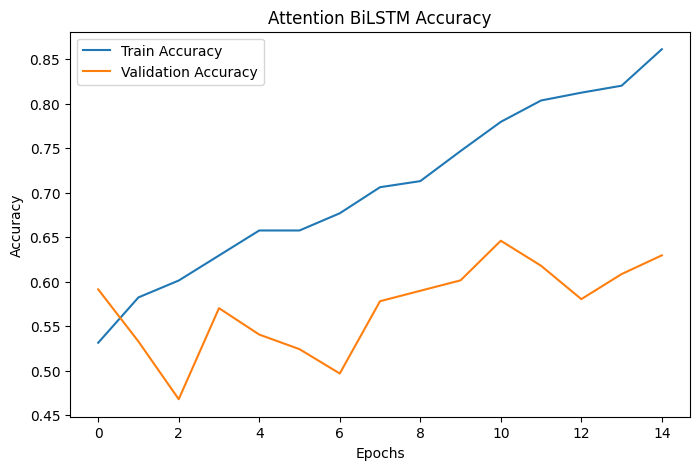

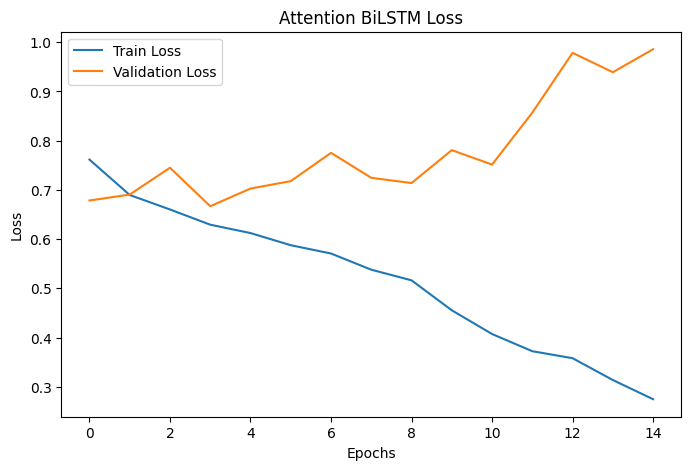

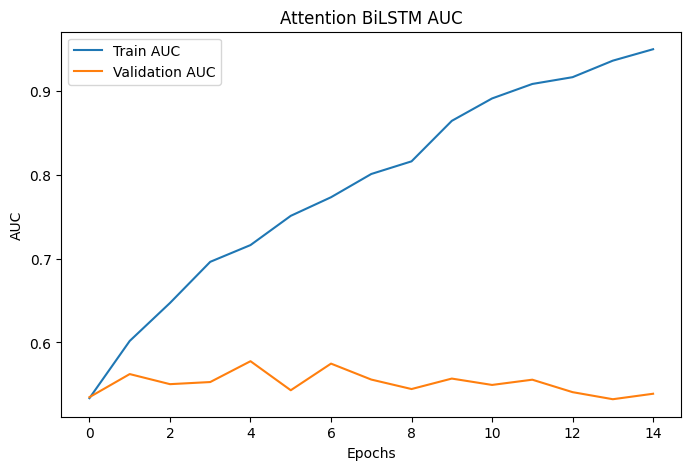

In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def tune_threshold(model, X_val, y_val, thresholds=np.arange(0.1, 0.9, 0.05)):
    y_prob = model.predict(X_val).ravel()

    rows = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        rows.append({
            "Threshold": round(float(t), 2),
            "Accuracy": accuracy_score(y_val, y_pred),
            "Precision": precision_score(y_val, y_pred, zero_division=0),
            "Recall": recall_score(y_val, y_pred, zero_division=0),
            "F1": f1_score(y_val, y_pred, zero_division=0)
        })

    return pd.DataFrame(rows)

lstm_threshold_results = tune_threshold(
    attention_lstm_model,
    X_test_seq,
    y_test_seq,
    thresholds=np.arange(0.1, 0.9, 0.05)
)

print(lstm_threshold_results)

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Attention BiLSTM Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Attention BiLSTM Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["auc"], label="Train AUC")
plt.plot(history.history["val_auc"], label="Validation AUC")
plt.title("Attention BiLSTM AUC")
plt.xlabel("Epochs")
plt.ylabel("AUC")
plt.legend()
plt.show()

In [64]:
all_results = pd.concat(
    {
        "Logistic Regression": lr_results,
        "Random Forest": rf_results,
        "XGBoost": xgb_results,
        "Attention BiLSTM": true_lstm_results
    }
)

print("\n========== FINAL MODEL COMPARISON ==========")
print(all_results.round(4))


========== FINAL MODEL COMPARISON ==========
                           Accuracy  Precision  Recall  F1-Score  \
Logistic Regression Train    0.8612     0.8125  0.0145    0.0284   
                    Test     0.8612     1.0000  0.0089    0.0177   
Random Forest       Train    1.0000     1.0000  1.0000    1.0000   
                    Test     0.8525     0.3125  0.0446    0.0781   
XGBoost             Train    0.8703     0.9595  0.0791    0.1461   
                    Test     0.8550     0.1000  0.0045    0.0085   
Attention BiLSTM    Train    0.3989     0.1846  0.9610    0.3097   
                    Test     0.3338     0.1503  0.8080    0.2535   

                           Balanced Accuracy  Specificity     MCC  ROC-AUC  
Logistic Regression Train             0.5070       0.9995  0.0969   0.6561  
                    Test              0.5045       1.0000  0.0877   0.6385  
Random Forest       Train             1.0000       1.0000  1.0000   1.0000  
                    Test         